# Module 09 — What this toy stack cannot do yet

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vvknyn/self-driving-ai-course/blob/main/notebooks/09_cutting_edge_research.ipynb)

Modules 00 through 08 are a relay you can read. This notebook does not add a `modules/09` folder, and it does not train a driver. Each section is one blind spot from that relay: a picture, the number the picture produced, then **one** paper.

A number next to a paper is a quote from that paper's abstract. A number next to a picture was printed by the cell above it. There is no `modules/09` to fill in.

**Predict first**, then run the cell. The paragraph after the cell says what was weird, and what a driver should care about.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

print("numpy", np.__version__)
print("matplotlib", plt.matplotlib.__version__)
print("course modules imported: no")


numpy 2.4.4
matplotlib 3.11.2
course modules imported: no


## 1. Module 00 — a good score can miss every person

Ten open-road crops. Three people. The dumbest driver names every crop "open road," because that is the most common name.

**Predict:** the accuracy looks like most of the folder. The recall on people is zero. Both can be true at once.


photos: 13
always-road accuracy: 0.7692
pedestrian recall: 0.0000


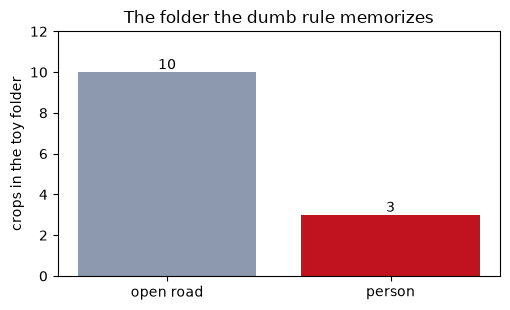

In [2]:
n_road, n_person = 10, 3
n = n_road + n_person
accuracy = n_road / n
recall = 0.0 / n_person
print(f"photos: {n}")
print(f"always-road accuracy: {accuracy:.4f}")
print(f"pedestrian recall: {recall:.4f}")

fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.bar(["open road", "person"], [n_road, n_person], color=["#8d99ae", "#c1121f"])
ax.set_ylabel("crops in the toy folder")
ax.set_title("The folder the dumb rule memorizes")
for i, v in enumerate([n_road, n_person]):
    ax.text(i, v + 0.15, str(v), ha="center")
ax.set_ylim(0, 12)
fig.tight_layout()
plt.show()


Accuracy is `0.7692`. Pedestrian recall is `0.0000`. Ten of the thirteen crops really are open road, so "about three quarters right" is the honest fraction, and it still names zero of the three people.

That is the weird part. A score that averages over the folder lets the asphalt outvote the person. A driver should care because the rare thing is the one you must not miss.

One paper. [Tsung-Yi Lin et al., Focal Loss for Dense Object Detection](https://arxiv.org/abs/1708.02002). The abstract says: "We discover that the extreme foreground-background class imbalance encountered during training of dense detectors is the central cause." It does not state a COCO AP. Do not invent one. The `0.7692` and the `0.0000` are this folder, not that paper.


## 2. Module 01 — one degree of pitch, and the far point runs away

A camera `1.5` m off the ground looks at a point on flat pavement. The ray that hits a point at range `Z` sits `arctan(1.5 / Z)` below the horizon. Tip the camera up by one degree and read that same ray as a new range.

**Predict:** `10` m barely moves. `40` m does not. The error grows with distance.


10 m true → 11.35 m read, error +1.35 m
20 m true → 26.10 m read, error +6.10 m
40 m true → 74.88 m read, error +34.88 m


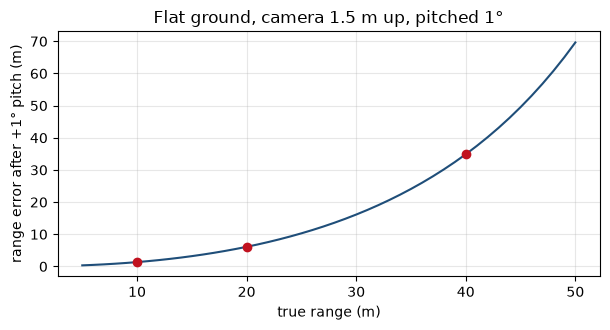

In [3]:
h = 1.5
bias_deg = 1.0
delta = np.deg2rad(bias_deg)
ranges = np.array([10.0, 20.0, 40.0])
theta = np.arctan(h / ranges)
z_hat = h / np.tan(theta - delta)
err = z_hat - ranges
for Z, zh, e in zip(ranges, z_hat, err):
    print(f"{Z:.0f} m true → {zh:.2f} m read, error {e:+.2f} m")

grid = np.linspace(5.0, 50.0, 46)
th = np.arctan(h / grid)
err_grid = h / np.tan(th - delta) - grid
fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.plot(grid, err_grid, color="#1f4e79")
ax.scatter(ranges, err, color="#c1121f", zorder=3)
ax.set_xlabel("true range (m)")
ax.set_ylabel("range error after +1° pitch (m)")
ax.set_title("Flat ground, camera 1.5 m up, pitched 1°")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


`10` m is read as `11.35` m, error `+1.35` m. `20` m is read as `26.10` m, error `+6.10` m. `40` m is read as `74.88` m, error `+34.88` m. One degree, and the far point has moved by more than the length of a bus.

A driver should care that a flat-ground guess gets worse as the thing gets farther, which is exactly where you most want the distance. This five-line camera is not the course's student pitch function. It is the picture of the assumption.

One paper. [Yan Wang et al., Pseudo-LiDAR from Visual Depth Estimation](https://arxiv.org/abs/1812.07179). The abstract says the approach raises "the detection accuracy of objects within the 30m range from the previous state-of-the-art of 22% to an unprecedented 74%" on KITTI. Those two percents are that abstract. They are not a measurement of this one-degree pitch. The connection is the complaint: an image is not yet a point in front of the bumper.


## 3. Module 02 — the loud loss eats the quiet one

Two tasks, one sum. A depth loss of `50` and a class loss of `0.2`. Nobody has reweighted them.

**Predict:** the sum is almost entirely the depth term. The class term is a rounding error.


depth loss: 50.0
class loss: 0.2
depth share of the sum: 0.9960
class share of the sum: 0.0040


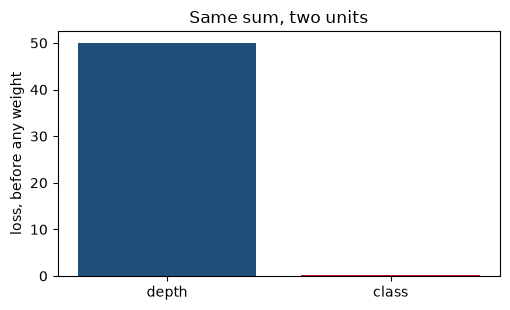

In [4]:
depth_loss, class_loss = 50.0, 0.2
total = depth_loss + class_loss
print(f"depth loss: {depth_loss:.1f}")
print(f"class loss: {class_loss:.1f}")
print(f"depth share of the sum: {depth_loss / total:.4f}")
print(f"class share of the sum: {class_loss / total:.4f}")

fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.bar(["depth", "class"], [depth_loss, class_loss], color=["#1f4e79", "#c1121f"])
ax.set_ylabel("loss, before any weight")
ax.set_title("Same sum, two units")
fig.tight_layout()
plt.show()


The depth term is `0.9960` of the sum. The class term is `0.0040`. A gradient step on that sum spends almost all of itself on depth. The class head can be wrong and the total barely notices.

A driver should care when one head is in meters and another is a probability. Adding them raw is not a plan for which mistake matters.

One paper. [Alex Kendall, Yarin Gal, and Roberto Cipolla, Multi-Task Learning Using Uncertainty to Weigh Losses for Scene Geometry and Semantics](https://arxiv.org/abs/1705.07115). The abstract says "the performance of such systems is strongly dependent on the relative weighting between each task's loss." It states no scalar. The `0.9960` is this toy sum, not their experiment.


## 4. Module 03 — a wrong depth drops the same pixel in a different cell

One pixel. Two depth guesses, `8` m and `24` m. Cells are `0.6` m long, the forward step the capstone uses for its bird's-eye grid. The pixel is painted into `floor(depth / 0.6)`.

**Predict:** the same pixel does not land in neighboring cells. It lands many meters apart.


depth 8.0 m → cell 13 → forward 7.8 m
depth 24.0 m → cell 40 → forward 24.0 m
same pixel, two cells, 16.2 m apart


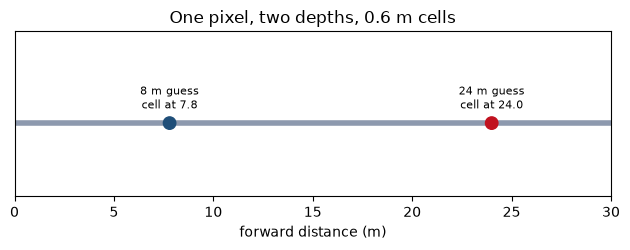

In [5]:
cell = 0.6
depths = np.array([8.0, 24.0])
idx = np.floor(depths / cell).astype(int)
landed = idx * cell
apart = float((idx[1] - idx[0]) * cell)
for d, i, z in zip(depths, idx, landed):
    print(f"depth {d:.1f} m → cell {int(i)} → forward {z:.1f} m")
print(f"same pixel, two cells, {apart:.1f} m apart")

fig, ax = plt.subplots(figsize=(6.4, 2.6))
ax.axhline(0.0, color="#8d99ae", lw=4)
ax.scatter(landed, [0, 0], s=80, color=["#1f4e79", "#c1121f"], zorder=3)
for z, d in zip(landed, depths):
    ax.text(z, 0.08, f"{d:.0f} m guess\ncell at {z:.1f}", ha="center", fontsize=8)
ax.set_xlim(0, 30)
ax.set_ylim(-0.4, 0.5)
ax.set_yticks([])
ax.set_xlabel("forward distance (m)")
ax.set_title("One pixel, two depths, 0.6 m cells")
fig.tight_layout()
plt.show()


The `8` m guess lands in cell `13`, at `7.8` m. The `24` m guess lands in cell `40`, at `24.0` m. The same pixel is `16.2` m apart. A depth error does not blur a neighbor. It teleports the feature down the road.

A driver should care because the map leg of the relay is only as honest as that depth. Smear the depth and the obstacle is a streak.

One paper. [Yinhao Li et al., BEVDepth](https://arxiv.org/abs/2206.10092). The abstract says "depth estimation in recent approaches is surprisingly inadequate given the fact that depth is essential to camera 3D detection," and that BEVDepth "achieves the new state-of-the-art 60.9% NDS on the challenging nuScenes test set." It also says "the NDS score of a camera model reaches 60%." That `60.9` is their camera model on the nuScenes test set. This notebook did not re-run it. It is not the `16.2` m gap above, and it does not belong on the chart in the last section.


## 5. Module 04 — a pole can sit in a cell and still be called empty

A cell is occupied when the object covers at least half of the cell. The cell is `1` m by `1` m. A pole is `0.10` m wide. A car is `1.60` m wide.

**Predict:** the car fills the cell. The pole does not. The pole is still in the cell.


pole 0.10 m → fraction 0.100 → occupied? False
car  1.60 m → fraction 1.000 → occupied? True


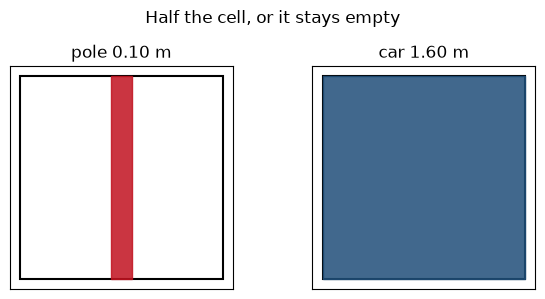

In [6]:
def covered_fraction(width_m, voxel_m=1.0):
    span = min(width_m, voxel_m)
    return (span * voxel_m) / (voxel_m ** 2)

threshold = 0.5
pole = covered_fraction(0.10)
car = covered_fraction(1.60)
print(f"pole 0.10 m → fraction {pole:.3f} → occupied? {pole >= threshold}")
print(f"car  1.60 m → fraction {car:.3f} → occupied? {car >= threshold}")

fig, axes = plt.subplots(1, 2, figsize=(6.2, 3.0))
for ax, title, width, color in (
    (axes[0], "pole 0.10 m", 0.10, "#c1121f"),
    (axes[1], "car 1.60 m", 1.60, "#1f4e79"),
):
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, lw=1.5))
    w = min(width, 1.0)
    ax.add_patch(plt.Rectangle(((1 - w) / 2, 0), w, 1, color=color, alpha=0.85))
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Half the cell, or it stays empty")
fig.tight_layout()
plt.show()


The pole covers `0.100` of the cell and is marked empty. The car covers `1.000` and is marked occupied. The pole did not leave. The rule refused to say its name.

A driver should care that "empty" can mean "too thin for the voxel," which is a bad time to meet a pole, a pedestrian, or a fallen sign.

One paper. [Xiaoyu Tian et al., Occ3D](https://arxiv.org/abs/2304.14365). The abstract says existing methods "typically focus on estimating 3D bounding boxes, neglecting finer geometric details and struggling to handle general, out-of-vocabulary objects." It states no mIoU. Do not invent one. The `0.100` is this cell, not their benchmark.


## 6. Module 05 — one cubic cannot be a fork

The road is one line until `12` m, then it splits. The left branch rises at `0.15` m of lateral per meter of forward. The right branch falls at the same rate. A single cubic is fit only to the left branch.

**Predict:** the cubic stays near the branch it saw. At `30` m it misses the other branch by several meters.


max |cubic - left branch|  = 0.188 m
max |cubic - right branch| = 5.436 m
at 30 m, cubic 2.736 m, left 2.700 m, right -2.700 m


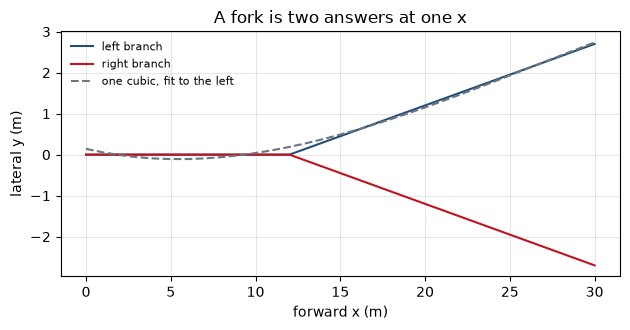

In [7]:
x = np.linspace(0.0, 30.0, 31)
y_left = np.where(x < 12.0, 0.0, 0.15 * (x - 12.0))
y_right = np.where(x < 12.0, 0.0, -0.15 * (x - 12.0))
coef = np.polyfit(x, y_left, 3)
y_hat = np.polyval(coef, x)
err_left = float(np.max(np.abs(y_hat - y_left)))
err_right = float(np.max(np.abs(y_hat - y_right)))
print(f"max |cubic - left branch|  = {err_left:.3f} m")
print(f"max |cubic - right branch| = {err_right:.3f} m")
print(f"at 30 m, cubic {y_hat[-1]:.3f} m, left {y_left[-1]:.3f} m, right {y_right[-1]:.3f} m")

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(x, y_left, label="left branch", color="#1f4e79")
ax.plot(x, y_right, label="right branch", color="#c1121f")
ax.plot(x, y_hat, "--", label="one cubic, fit to the left", color="#6c757d")
ax.set_xlabel("forward x (m)")
ax.set_ylabel("lateral y (m)")
ax.set_title("A fork is two answers at one x")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


The cubic's worst miss on the branch it was fit to is `0.188` m. The kink at `12` m is not a cubic, so even the observed branch is not exact. Its worst miss on the other branch is `5.436` m. At `30` m the curve says `2.736` m, the left branch is `2.700` m, and the right branch is `-2.700` m.

A driver should care at the moment the road offers two futures. One polynomial has already chosen.

One paper. [Huijie Wang et al., OpenLane-V2](https://arxiv.org/abs/2304.10440). The abstract says OpenLane-V2 "consists of 2,000 annotated road scenes that describe traffic elements and their correlation to the lanes." That `2,000` is a count of scenes. It is not the `5.436` m miss. The miss is this notebook's geometry.


## 7. Module 06 — the plan does not look at the map

Occupancy is all zeros, then all ones. The obstacle list stays `x = 10`, `y = 1.2`. The planner is handed the obstacle list. This is a sketch of the capstone step, not a call to that class.

**Predict:** the occupancy checksum changes. The planner's input does not.


planner sees (occ zeros): [[10.0, 1.2]]
planner sees (occ ones):  [[10.0, 1.2]]
same planner input? True
occupancy checksum, zeros: 0.0
occupancy checksum, ones:  32.0


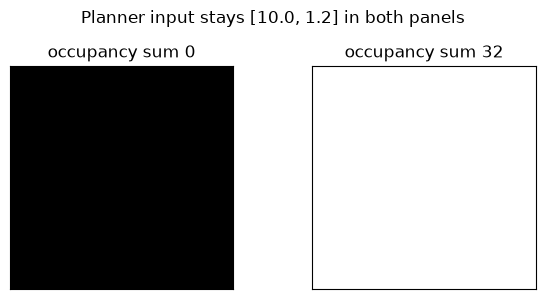

In [8]:
def planner_sees(occ, obstacles):
    checksum = float(np.sum(occ))
    detections = np.array([[o["x"], o["y"]] for o in obstacles], dtype=float)
    return detections, checksum

obstacles = [{"x": 10.0, "y": 1.2}]
det_a, sum_a = planner_sees(np.zeros((1, 1, 4, 4, 2)), obstacles)
det_b, sum_b = planner_sees(np.ones((1, 1, 4, 4, 2)), obstacles)
print("planner sees (occ zeros):", det_a.tolist())
print("planner sees (occ ones): ", det_b.tolist())
print("same planner input?", bool(np.array_equal(det_a, det_b)))
print("occupancy checksum, zeros:", sum_a)
print("occupancy checksum, ones: ", sum_b)

fig, axes = plt.subplots(1, 2, figsize=(6.2, 3.0))
axes[0].imshow(np.zeros((4, 4)), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("occupancy sum 0")
axes[1].imshow(np.ones((4, 4)), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("occupancy sum 32")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Planner input stays [10.0, 1.2] in both panels")
fig.tight_layout()
plt.show()


The planner sees `[[10.0, 1.2]]` both times. `same planner input?` is `True`. The checksum goes from `0` to `32`, because the tensor is `(1, 1, 4, 4, 2)` and the second call fills it with ones. Painting the whole map did not move the plan.

A driver should care that the map runner can finish the leg and drop the baton. The wheel then steers from a list that never looked at the map.

One paper. [Yihan Hu et al., Planning-oriented Autonomous Driving](https://arxiv.org/abs/2212.10156). The abstract says separate heads "might suffer from accumulative errors or deficient task coordination," and that a framework "should be devised and optimized in pursuit of the ultimate goal, i.e., planning." It states no scalar. Do not invent an NDS for it.


## 8. Module 07 — a perfect lane score while the gap closes

The ego sits on the lane center, so the cross-track error is zero by construction. Speed is `12` m/s. A lead car is stopped at `30` m. Ten steps of `0.1` s. Nobody brakes.

**Predict:** the cross-track error stays zero. The gap gets smaller. Zero is not "safe."


gap starts 28.8 m and ends 18.0 m
mean |cte|: 0.0000 m
steps: 10


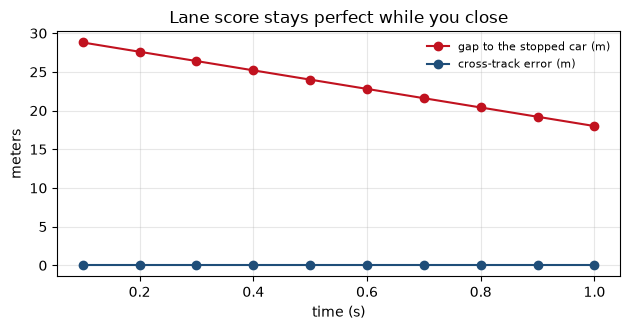

In [9]:
ego_x = 0.0
lead_x = 30.0
v = 12.0
dt = 0.1
gaps, ctes = [], []
for _ in range(10):
    ego_x += v * dt
    gaps.append(lead_x - ego_x)
    ctes.append(0.0)
print(f"gap starts {gaps[0]:.1f} m and ends {gaps[-1]:.1f} m")
print(f"mean |cte|: {float(np.mean(np.abs(ctes))):.4f} m")
print(f"steps: {len(gaps)}")

t = np.arange(1, 11) * dt
fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(t, gaps, marker="o", color="#c1121f", label="gap to the stopped car (m)")
ax.plot(t, ctes, marker="o", color="#1f4e79", label="cross-track error (m)")
ax.set_xlabel("time (s)")
ax.set_ylabel("meters")
ax.set_title("Lane score stays perfect while you close")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


The gap starts at `28.8` m and ends at `18.0` m. Mean absolute cross-track error is `0.0000` m. In one second the bicycle ate `12` m of a gap and the lane score did not flinch, because the lane score is not looking at the car ahead.

A driver should care that a comfort number about the paint can be perfect on the way into the trunk of a stopped car. This is a cartoon, not a tire model.

One paper. [Daniel Dauner et al., NAVSIM](https://arxiv.org/abs/2406.15349). The abstract says "open-loop evaluation with real data is easy, but these results do not reflect closed-loop performance." It also says a CVPR 2024 competition had "143 teams submitted 463 entries." Those counts are not a cross-track error. The `0.0000` m is this cartoon.


## 9. Module 08 — a flattering score can ignore the camera

Eight future points, `1.2` m apart, straight down the log. A predictor that copies the log has no image. A person stands at `(6.0, 0.0)`, which is one of those points.

**Predict:** open-loop error against the log is zero. Distance from the predicted path to the person is also zero. The metric is happy and the path is not.


open-loop L2 to the log: 0.0000 m
closest predicted point to the person: 0.0000 m
image used: no


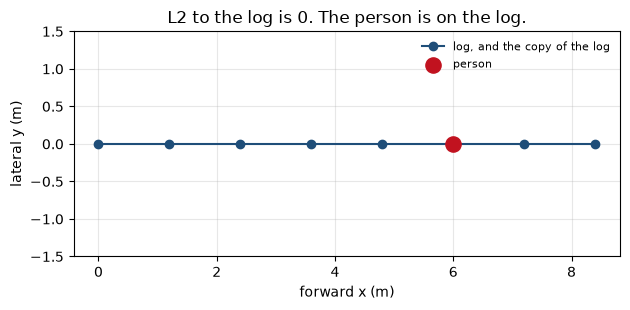

In [10]:
log = np.stack([np.arange(8) * 1.2, np.zeros(8)], axis=1)
pred = log.copy()
person = np.array([6.0, 0.0])
l2 = float(np.mean(np.linalg.norm(pred - log, axis=1)))
closest = float(np.min(np.linalg.norm(pred - person, axis=1)))
print(f"open-loop L2 to the log: {l2:.4f} m")
print(f"closest predicted point to the person: {closest:.4f} m")
print("image used: no")

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.plot(log[:, 0], log[:, 1], marker="o", color="#1f4e79", label="log, and the copy of the log")
ax.scatter([person[0]], [person[1]], s=120, color="#c1121f", zorder=3, label="person")
ax.set_xlabel("forward x (m)")
ax.set_ylabel("lateral y (m)")
ax.set_title("L2 to the log is 0. The person is on the log.")
ax.legend(frameon=False, fontsize=8)
ax.set_ylim(-1.5, 1.5)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


Open-loop L2 to the log is `0.0000` m. The closest predicted point to the person is `0.0000` m. No image was used. Copying yesterday's path is a perfect score on an exam that grades yesterday's path, and the person is standing on it.

A driver should care that this is the shape of the capstone's honesty problem. The cameras there are noise, the planner reads ground-truth points, and a green test means the bicycle moved. A flattering open-loop number is not a safety case. This cartoon's zero is not a paper's result.

One paper. [Jiang-Tian Zhai et al., Rethinking the Open-Loop Evaluation of End-to-End Autonomous Driving in nuScenes](https://arxiv.org/abs/2305.10430). The abstract says a simple method that does not use camera images or LiDAR "achieves similar end-to-end planning performance on the nuScenes dataset with other perception-based methods, reducing the average L2 error by about 20%." It also says the perception-based methods still had an advantage on collision rate. That "about 20%" is their sentence. It is not this `0.0000`.


## 10. One chart, and only one pair of numbers

The next cell stores quotes copied from the abstracts above. It prints every scalar it can read out of those quotes. It draws a bar only for the pair that shares a metric: image-based detection accuracy within `30` m, previous result versus the paper's result.

**Predict:** `60.9` NDS, "about 20%" L2, `2,000` scenes, and `143` / `463` competition counts will be printed and will not be drawn. They are different quantities.


scalars read out of the quotes
  Pseudo-LiDAR: numbers [30.0, 22.0, 74.0]  percents [22.0, 74.0]
    quote: raising the detection accuracy of objects within the 30m range from the previous state-of-the-art of 22% to an unprecedented 74%
  BEVDepth: numbers [60.9]  percents [60.9]
    quote: achieves the new state-of-the-art 60.9% NDS on the challenging nuScenes test set
  OpenLane-V2: numbers [2000.0]  percents []
    quote: consists of 2,000 annotated road scenes
  NAVSIM: numbers [143.0, 463.0]  percents []
    quote: 143 teams submitted 463 entries
  Zhai et al.: numbers [20.0]  percents [20.0]
    quote: reducing the average L2 error by about 20%
plotted percents: [22.0, 74.0]
percentage-point gap: 52.0


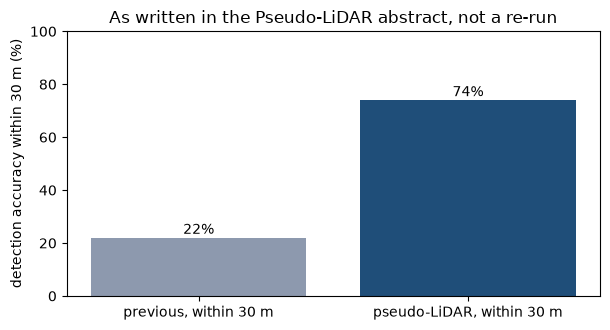

In [11]:
QUOTES = [
    {
        "paper": "Pseudo-LiDAR",
        "url": "https://arxiv.org/abs/1812.07179",
        "quote": "raising the detection accuracy of objects within the 30m range from the previous state-of-the-art of 22% to an unprecedented 74%",
        "plot": True,
    },
    {
        "paper": "BEVDepth",
        "url": "https://arxiv.org/abs/2206.10092",
        "quote": "achieves the new state-of-the-art 60.9% NDS on the challenging nuScenes test set",
        "plot": False,
    },
    {
        "paper": "OpenLane-V2",
        "url": "https://arxiv.org/abs/2304.10440",
        "quote": "consists of 2,000 annotated road scenes",
        "plot": False,
    },
    {
        "paper": "NAVSIM",
        "url": "https://arxiv.org/abs/2406.15349",
        "quote": "143 teams submitted 463 entries",
        "plot": False,
    },
    {
        "paper": "Zhai et al.",
        "url": "https://arxiv.org/abs/2305.10430",
        "quote": "reducing the average L2 error by about 20%",
        "plot": False,
    },
]

def scalars(quote):
    import re
    # A digit glued to a letter (the 2 in L2) is not a number the abstract stated.
    nums = re.findall(r"(?<![A-Za-z])\d[\d,]*(?:\.\d+)?", quote)
    percents = re.findall(r"(?<![A-Za-z])(\d+(?:\.\d+)?)%", quote)
    return (
        [float(x.replace(",", "")) for x in nums],
        [float(x) for x in percents],
    )

print("scalars read out of the quotes")
plot_labels, plot_values = [], []
for row in QUOTES:
    found, percents = scalars(row["quote"])
    print(f"  {row['paper']}: numbers {found}  percents {percents}")
    print(f"    quote: {row['quote']}")
    if row["plot"]:
        plot_labels = ["previous, within 30 m", "pseudo-LiDAR, within 30 m"]
        plot_values = percents
print("plotted percents:", plot_values)
print("percentage-point gap:", plot_values[1] - plot_values[0])

fig, ax = plt.subplots(figsize=(6.2, 3.4))
bars = ax.bar(plot_labels, plot_values, color=["#8d99ae", "#1f4e79"])
for bar, value in zip(bars, plot_values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 1.5, f"{value:.0f}%", ha="center")
ax.set_ylim(0, 100)
ax.set_ylabel("detection accuracy within 30 m (%)")
ax.set_title("As written in the Pseudo-LiDAR abstract, not a re-run")
fig.tight_layout()
plt.show()


The two bars are one sentence. `22` is the previous image-based accuracy within `30` m. `74` is what that abstract claims after the pseudo-LiDAR representation. The vertical axis starts at `0` so the gap stays a gap of `52` percentage points inside that sentence. They were not measured on our one-degree pitch.

`60.9` is NDS on nuScenes test, a different exam. "About `20`" is a relative L2 cut, and the abstract's word is "about." `2,000` counts scenes. `143` and `463` count a 2024 competition. None of those belong on this axis. Focal loss, the uncertainty paper, Occ3D, and UniAD stated no scalar in the abstract, so they are not in the list.


## 11. Pick one paper

One blind spot, one PDF. Stop when the six lines are full.

| If the failure you can point at is… | Read this abstract |
| :--- | :--- |
| A high accuracy that still misses the rare person | [Focal loss](https://arxiv.org/abs/1708.02002) |
| An image that is not yet a point in front of the bumper | [Pseudo-LiDAR](https://arxiv.org/abs/1812.07179) |
| Two losses in different units, added raw | [Kendall, Gal, and Cipolla](https://arxiv.org/abs/1705.07115) |
| A depth guess that teleports a pixel down the road | [BEVDepth](https://arxiv.org/abs/2206.10092) |
| A thin object marked empty, or a box that drops the shape | [Occ3D](https://arxiv.org/abs/2304.14365) |
| One curve where the road forks | [OpenLane-V2](https://arxiv.org/abs/2304.10440) |
| A plan that never looks at the map | [UniAD](https://arxiv.org/abs/2212.10156) |
| A lane score that stays perfect while the gap closes | [NAVSIM](https://arxiv.org/abs/2406.15349) |
| An open-loop score that can ignore the camera | [Zhai et al.](https://arxiv.org/abs/2305.10430) |

```text
Paper:
Question (one sentence):
Module hook (a file under modules/00–08):
Evidence (a quote from the abstract, or "abstract gives none"):
Limitation (from the abstract, or "not in the abstract"):
What I will not claim:
```

The pictures above are toys. The quotes are the abstracts. A blog number that is not in the quote list was not fetched for this notebook.
